# MW Training + Coefficient Finetuning Workflow

이 노트북은 `test_qaoa/qaoa.ipynb`의 기본 흐름을 유지하면서, 두 단계 최적화를 수행합니다.

1. `max_weight` truncation만 사용해서 먼저 QAOA 파라미터를 학습합니다.
2. 그렇게 얻은 theta를 `build_thetas`로 사용하여 `build_min_abs` coefficient truncation을 켠 surrogate로 다시 finetuning합니다.

coefficient truncation은 특정 theta 근방에서만 잘 맞기 때문에, finetuning 단계에서는 일정 interval마다 현재 theta로 surrogate를 다시 컴파일하여 truncation 방향성을 계속 맞춥니다.


In [1]:
import gc
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

NOTEBOOK_DIR = Path('/home/ubuntu/PPS-lab/test_qaoa')
REPO_ROOT = NOTEBOOK_DIR.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from src_tensor.api import compile_expval_program
from make_graph import _make_erdos_renyi_graph as make_erdos_renyi_graph
from qaoa_surrogate_common import (
    build_maxcut_observable,
    build_qaoa_circuit,
    build_qaoa_theta_init_flattened_tqa,
    build_qaoa_theta_init_tqa,
    expected_cut_from_sum_zz,
)


def cleanup_memory(device: str) -> None:
    gc.collect()
    if str(device).startswith('cuda') and torch.cuda.is_available():
        torch.cuda.empty_cache()


def extract_compile_resources(program):
    psum = program.psum_union
    total_nnz = 0
    for step in psum.steps:
        total_nnz += int(step.mat_const._nnz())
        total_nnz += int(step.mat_cos._nnz())
        total_nnz += int(step.mat_sin._nnz())
    return {
        'terms_after_zero_filter': int(psum.x_mask.shape[0]),
        'n_steps': int(len(psum.steps)),
        'nnz_total': int(total_nnz),
    }


def plot_graph_circle(n_qubits, edges, save_path=None):
    theta = np.linspace(0, 2 * np.pi, int(n_qubits), endpoint=False)
    x = np.cos(theta)
    y = np.sin(theta)

    fig, ax = plt.subplots(figsize=(6, 6))
    for u, v in edges:
        ax.plot([x[int(u)], x[int(v)]], [y[int(u)], y[int(v)]], color='gray', alpha=0.45)
    ax.scatter(x, y, s=180, c='skyblue', edgecolors='black')
    for i in range(int(n_qubits)):
        ax.text(x[i] * 1.1, y[i] * 1.1, str(i), ha='center', va='center')
    ax.set_axis_off()
    ax.set_title(f'Erdos-Renyi Graph (N={n_qubits})')
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=160)
    plt.show()


def float_tag(x: float) -> str:
    text = f'{float(x):.0e}' if abs(float(x)) < 1e-2 else str(float(x))
    return text.replace('-', 'm').replace('.', 'p')


def save_json(path: Path, payload) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding='utf-8')


## 1. Configuration

아래 셀만 바꾸면 같은 그래프와 같은 초기화, 같은 truncation 설정으로 재현되도록 구성했습니다.


In [ ]:
# ---------------------------
# User configuration
# ---------------------------

RUN_NAME = ''  # 비워두면 아래 설정으로 자동 이름 생성

N_QUBITS = 20
P_LAYERS = 5
EDGE_PROB = 0.25
SEED = 42

MAX_WEIGHT = 3
DELTA_T = 0.8
INIT_STRATEGY = 'flattened_tqa'  # 'flattened_tqa', 'tqa', 'random'
FLATTEN_ALPHA = 0.5

MW_TRAIN_STEPS = 100
COEFF_FINETUNE_STEPS = 100
LR_MW = 0.05
LR_COEFF = 0.01

COEFF_BUILD_MIN_ABS = 1e-3   # 예: 1e-3 또는 5e-4
COEFF_REBUILD_INTERVAL = 10  # 몇 step마다 build_thetas=current_theta로 재컴파일할지

CHECKPOINT_STEPS_MW = [1, 10, 25, MW_TRAIN_STEPS]
CHECKPOINT_STEPS_COEFF = [1, 10, 25, COEFF_FINETUNE_STEPS]

CHUNK_SIZE = 20_000_000
PARALLEL_COMPILE = False
ENSURE_CONNECTED = True
MAX_TRIES = 300
LOG_EVERY = 10

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
PRESET = 'hybrid' if DEVICE.startswith('cuda') else 'cpu'
DTYPE = torch.float64

torch.manual_seed(SEED)
np.random.seed(SEED)

if RUN_NAME.strip() == '':
    run_name = (
        f"Q{N_QUBITS}_L{P_LAYERS}_p{str(EDGE_PROB).replace('.', 'p')}_"
        f"mw{MAX_WEIGHT}_seed{SEED}_bma{float_tag(COEFF_BUILD_MIN_ABS)}"
    )
else:
    run_name = RUN_NAME.strip()

RESULTS_ROOT = NOTEBOOK_DIR / 'mw_training_coeff_finetuning_results'
OUTPUT_DIR = RESULTS_ROOT / run_name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

config_payload = {
    'run_name': run_name,
    'n_qubits': int(N_QUBITS),
    'p_layers': int(P_LAYERS),
    'edge_prob': float(EDGE_PROB),
    'seed': int(SEED),
    'max_weight': int(MAX_WEIGHT),
    'delta_t': float(DELTA_T),
    'init_strategy': str(INIT_STRATEGY),
    'flatten_alpha': float(FLATTEN_ALPHA),
    'mw_train_steps': int(MW_TRAIN_STEPS),
    'coeff_finetune_steps': int(COEFF_FINETUNE_STEPS),
    'lr_mw': float(LR_MW),
    'lr_coeff': float(LR_COEFF),
    'coeff_build_min_abs': float(COEFF_BUILD_MIN_ABS),
    'coeff_rebuild_interval': int(COEFF_REBUILD_INTERVAL),
    'checkpoint_steps_mw': [int(x) for x in CHECKPOINT_STEPS_MW],
    'checkpoint_steps_coeff': [int(x) for x in CHECKPOINT_STEPS_COEFF],
    'chunk_size': int(CHUNK_SIZE),
    'parallel_compile': bool(PARALLEL_COMPILE),
    'device': str(DEVICE),
    'preset': str(PRESET),
}
save_json(OUTPUT_DIR / 'notebook_config.json', config_payload)

print(f'Device: {DEVICE}')
print(f'Output dir: {OUTPUT_DIR}')
print(json.dumps(config_payload, indent=2))

Device: cuda
Output dir: /home/ubuntu/PPS-lab/test_qaoa/mw_training_coeff_finetuning_results/Q15_L5_p0p25_mw3_seed42_bma1em03
{
  "run_name": "Q15_L5_p0p25_mw3_seed42_bma1em03",
  "n_qubits": 15,
  "p_layers": 5,
  "edge_prob": 0.25,
  "seed": 42,
  "max_weight": 3,
  "delta_t": 0.8,
  "init_strategy": "flattened_tqa",
  "flatten_alpha": 0.5,
  "mw_train_steps": 150,
  "coeff_finetune_steps": 100,
  "lr_mw": 0.05,
  "lr_coeff": 0.01,
  "coeff_build_min_abs": 0.001,
  "coeff_rebuild_interval": 10,
  "checkpoint_steps_mw": [
    1,
    10,
    50,
    150
  ],
  "checkpoint_steps_coeff": [
    1,
    10,
    50,
    100
  ],
  "chunk_size": 20000000,
  "parallel_compile": false,
  "device": "cuda",
  "preset": "hybrid"
}


Generated graph with 26 edges.


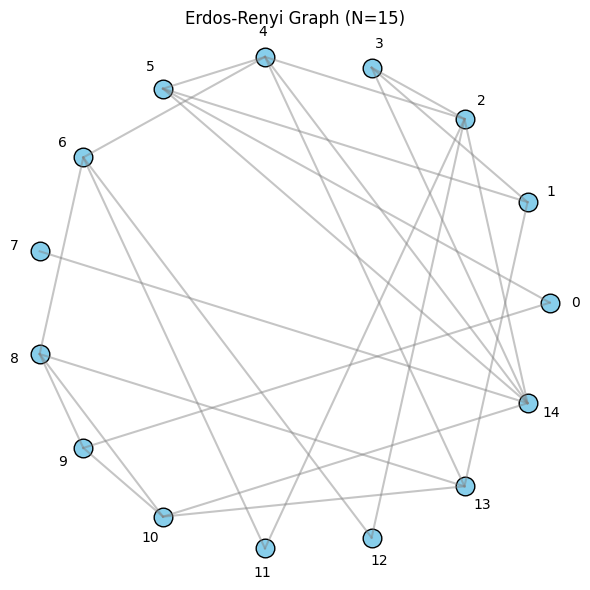

In [3]:
edges = make_erdos_renyi_graph(
    n_qubits=N_QUBITS,
    edge_prob=EDGE_PROB,
    seed=SEED,
    ensure_connected=ENSURE_CONNECTED,
    max_tries=MAX_TRIES,
)
m_edges = len(edges)

graph_payload = {
    'n_qubits': int(N_QUBITS),
    'edge_prob': float(EDGE_PROB),
    'seed': int(SEED),
    'ensure_connected': bool(ENSURE_CONNECTED),
    'edges': [[int(u), int(v)] for (u, v) in edges],
    'n_edges': int(m_edges),
}
save_json(OUTPUT_DIR / 'graph_edges.json', graph_payload)

print(f'Generated graph with {m_edges} edges.')
plot_graph_circle(N_QUBITS, edges, save_path=OUTPUT_DIR / 'graph.png')


## 2. Build QAOA Circuit and Helper Functions

아래 셀에서 회로, 초기화, 컴파일, 그리고 두 종류의 학습 루프를 정의합니다.


In [4]:
circuit, n_params = build_qaoa_circuit(N_QUBITS, edges, P_LAYERS)
zz_obj = build_maxcut_observable(N_QUBITS, edges)


def build_initial_theta_np(init_strategy: str) -> np.ndarray:
    key = str(init_strategy).strip().lower()
    if key == 'tqa':
        return build_qaoa_theta_init_tqa(
            p_layers=P_LAYERS,
            n_edges=m_edges,
            n_qubits=N_QUBITS,
            delta_t=DELTA_T,
            dtype=np.float64,
        )
    if key == 'flattened_tqa':
        return build_qaoa_theta_init_flattened_tqa(
            p_layers=P_LAYERS,
            n_edges=m_edges,
            n_qubits=N_QUBITS,
            delta_t=DELTA_T,
            flatten_alpha=FLATTEN_ALPHA,
            dtype=np.float64,
        )
    if key == 'random':
        return np.random.uniform(low=0.0, high=np.pi, size=(2 * P_LAYERS,)).astype(np.float64)
    raise ValueError(f'Unknown INIT_STRATEGY: {init_strategy}')


def compile_qaoa_program(*, build_thetas=None, build_min_abs=None, max_weight_override=MAX_WEIGHT):
    overrides = {
        'chunk_size': int(CHUNK_SIZE),
    }
    if max_weight_override is not None:
        overrides['max_weight'] = int(max_weight_override)

    compile_start = time.time()
    program = compile_expval_program(
        circuit=circuit,
        observables=[zz_obj],
        preset=PRESET,
        preset_overrides=overrides,
        build_thetas=build_thetas,
        build_min_abs=build_min_abs,
        parallel_compile=bool(PARALLEL_COMPILE),
    )
    compile_seconds = time.time() - compile_start
    info = extract_compile_resources(program)
    info['compile_seconds'] = float(compile_seconds)
    info['build_min_abs'] = None if build_min_abs is None else float(build_min_abs)
    return program, info


def train_with_fixed_program(*, program, thetas, n_edges, steps, lr, checkpoint_steps, stage_name):
    history = []
    checkpoints = {'step_0': thetas.detach().cpu().numpy().tolist()}
    optimizer = torch.optim.Adam([thetas], lr=float(lr))

    print(f'Starting {stage_name} for {steps} steps...')
    for step in range(int(steps)):
        optimizer.zero_grad(set_to_none=True)
        loss = program.expval(thetas, obs_index=0)
        if not bool(loss.requires_grad):
            raise RuntimeError(
                'loss does not require gradients. Recompile without coefficient pruning '
                'or reduce build_min_abs.'
            )
        loss.backward()
        optimizer.step()

        sum_zz = float(loss.detach().cpu().item())
        expected_cut = float(expected_cut_from_sum_zz(sum_zz, n_edges))
        history.append({
            'step': int(step + 1),
            'sum_zz': float(sum_zz),
            'expected_cut': float(expected_cut),
        })

        if (step + 1) in set(int(x) for x in checkpoint_steps):
            checkpoints[f'step_{step + 1}'] = thetas.detach().cpu().numpy().tolist()

        if ((step + 1) % int(LOG_EVERY) == 0) or (step == 0) or (step + 1 == int(steps)):
            print(
                f"[{stage_name}] step={step + 1:04d} "
                f"sum<ZZ>={sum_zz:+.6f} E[cut]={expected_cut:.6f}"
            )

    return history, checkpoints, thetas.detach().cpu().numpy()


def train_with_periodic_rebuild(
    *,
    start_thetas_np,
    n_edges,
    steps,
    lr,
    checkpoint_steps,
    build_min_abs,
    rebuild_interval,
    stage_name,
):
    thetas = torch.nn.Parameter(
        torch.tensor(np.asarray(start_thetas_np), dtype=DTYPE, device=DEVICE)
    )
    optimizer = torch.optim.Adam([thetas], lr=float(lr))

    history = []
    checkpoints = {'step_0': thetas.detach().cpu().numpy().tolist()}
    rebuild_log = []

    anchor = thetas.detach().clone()
    program, compile_info = compile_qaoa_program(
        build_thetas=anchor,
        build_min_abs=float(build_min_abs),
    )
    rebuild_log.append({
        'rebuild_index': 0,
        'after_step': 0,
        **compile_info,
    })

    print(
        f"Starting {stage_name} for {steps} steps "
        f"with build_min_abs={build_min_abs:.1e} and rebuild_interval={rebuild_interval}."
    )
    for step in range(int(steps)):
        optimizer.zero_grad(set_to_none=True)
        loss = program.expval(thetas, obs_index=0)
        if not bool(loss.requires_grad):
            raise RuntimeError(
                'loss does not require gradients under the current coefficient truncation. '
                'Use a smaller COEFF_BUILD_MIN_ABS or rebuild more often.'
            )
        loss.backward()
        optimizer.step()

        sum_zz = float(loss.detach().cpu().item())
        expected_cut = float(expected_cut_from_sum_zz(sum_zz, n_edges))
        history.append({
            'step': int(step + 1),
            'sum_zz': float(sum_zz),
            'expected_cut': float(expected_cut),
        })

        if (step + 1) in set(int(x) for x in checkpoint_steps):
            checkpoints[f'step_{step + 1}'] = thetas.detach().cpu().numpy().tolist()

        if ((step + 1) % int(LOG_EVERY) == 0) or (step == 0) or (step + 1 == int(steps)):
            print(
                f"[{stage_name}] step={step + 1:04d} "
                f"sum<ZZ>={sum_zz:+.6f} E[cut]={expected_cut:.6f}"
            )

        need_rebuild = (
            int(rebuild_interval) > 0
            and (step + 1) < int(steps)
            and ((step + 1) % int(rebuild_interval) == 0)
        )
        if need_rebuild:
            del program
            cleanup_memory(DEVICE)
            anchor = thetas.detach().clone()
            program, compile_info = compile_qaoa_program(
                build_thetas=anchor,
                build_min_abs=float(build_min_abs),
            )
            rebuild_log.append({
                'rebuild_index': int(len(rebuild_log)),
                'after_step': int(step + 1),
                **compile_info,
            })

    del program
    cleanup_memory(DEVICE)
    return history, checkpoints, thetas.detach().cpu().numpy(), rebuild_log


def plot_history(history, title, save_path=None):
    steps = [row['step'] for row in history]
    exp_cut = [row['expected_cut'] for row in history]
    sum_zz = [row['sum_zz'] for row in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(steps, exp_cut, color='teal', linewidth=2)
    axes[0].set_xlabel('Step')
    axes[0].set_ylabel('Expected Cut')
    axes[0].set_title(f'{title}: Expected Cut')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(steps, sum_zz, color='tab:orange', linewidth=2)
    axes[1].set_xlabel('Step')
    axes[1].set_ylabel('Sum <ZZ>')
    axes[1].set_title(f'{title}: Sum <ZZ>')
    axes[1].grid(True, alpha=0.3)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=160)
    plt.show()

## 3. Stage A: MW-Only Training

먼저 `max_weight`만 켠 상태로 학습합니다. 이 단계의 최종 theta가 coefficient finetuning의 시작점이 됩니다.


propagate: 100%|██████████| 220/220 [00:04<00:00, 48.40it/s]


[PPS Info] Propagation complete. Terms generated: 2,768
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 2,768 -> 120 terms kept (4.33526012%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 220 steps...


zero-filter: 100%|██████████| 220/220 [00:00<00:00, 1038.40it/s, step=0 rows=32 cols=26 nnz=6]      


MW compile info:
{
  "terms_after_zero_filter": 120,
  "n_steps": 220,
  "nnz_total": 17636,
  "compile_seconds": 4.766047954559326,
  "build_min_abs": null
}
Starting mw-train for 150 steps...
[mw-train] step=0001 sum<ZZ>=-10.059070 E[cut]=18.029535
[mw-train] step=0010 sum<ZZ>=-12.568995 E[cut]=19.284497
[mw-train] step=0020 sum<ZZ>=-12.769052 E[cut]=19.384526
[mw-train] step=0030 sum<ZZ>=-12.955202 E[cut]=19.477601
[mw-train] step=0040 sum<ZZ>=-13.030157 E[cut]=19.515079
[mw-train] step=0050 sum<ZZ>=-13.060287 E[cut]=19.530144
[mw-train] step=0060 sum<ZZ>=-13.062618 E[cut]=19.531309
[mw-train] step=0070 sum<ZZ>=-13.069196 E[cut]=19.534598
[mw-train] step=0080 sum<ZZ>=-13.068983 E[cut]=19.534492
[mw-train] step=0090 sum<ZZ>=-13.069588 E[cut]=19.534794
[mw-train] step=0100 sum<ZZ>=-13.069744 E[cut]=19.534872
[mw-train] step=0110 sum<ZZ>=-13.069750 E[cut]=19.534875
[mw-train] step=0120 sum<ZZ>=-13.069785 E[cut]=19.534893
[mw-train] step=0130 sum<ZZ>=-13.069788 E[cut]=19.534894
[mw-trai

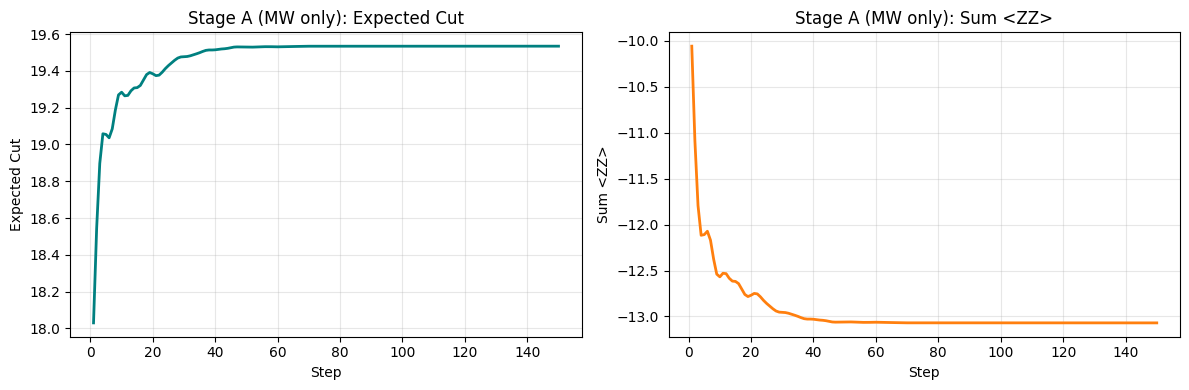

In [5]:
init_theta_np = build_initial_theta_np(INIT_STRATEGY)
thetas_mw = torch.nn.Parameter(torch.tensor(init_theta_np, dtype=DTYPE, device=DEVICE))

program_mw, mw_compile_info = compile_qaoa_program(build_thetas=None, build_min_abs=None, max_weight_override = MAX_WEIGHT)
print('MW compile info:')
print(json.dumps(mw_compile_info, indent=2))

mw_history, mw_checkpoints, trained_thetas_mw_np = train_with_fixed_program(
    program=program_mw,
    thetas=thetas_mw,
    n_edges=m_edges,
    steps=MW_TRAIN_STEPS,
    lr=LR_MW,
    checkpoint_steps=CHECKPOINT_STEPS_MW,
    stage_name='mw-train',
)
del program_mw
cleanup_memory(DEVICE)

mw_log = {
    'config': config_payload,
    'graph_path': str(OUTPUT_DIR / 'graph_edges.json'),
    'compile_info': mw_compile_info,
    'initial_thetas': init_theta_np.tolist(),
    'final_thetas': trained_thetas_mw_np.tolist(),
    'checkpoint_thetas': mw_checkpoints,
    'history': mw_history,
}
save_json(OUTPUT_DIR / 'mw_training_log.json', mw_log)

mw_initial_cut = mw_history[0]['expected_cut'] if mw_history else None
mw_final_cut = mw_history[-1]['expected_cut'] if mw_history else None
print(f'MW stage initial expected cut: {mw_initial_cut:.6f}')
print(f'MW stage final expected cut:   {mw_final_cut:.6f}')

plot_history(mw_history, 'Stage A (MW only)', save_path=OUTPUT_DIR / 'mw_training_curve.png')


## 4. Stage B: Coefficient-Truncated Finetuning

이제 Stage A에서 얻은 theta를 `build_thetas`로 사용해서 `build_min_abs` 기반 coefficient truncation을 켠 surrogate를 만듭니다.
학습 중 theta가 이동하므로, `COEFF_REBUILD_INTERVAL`마다 현재 theta로 다시 컴파일하여 truncation anchor를 업데이트합니다.


propagate: 100%|██████████| 220/220 [00:04<00:00, 54.48it/s]


[PPS Info] Propagation complete. Terms generated: 1,160
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 1,160 -> 68 terms kept (5.86206897%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 220 steps...


zero-filter: 100%|██████████| 220/220 [00:00<00:00, 1048.07it/s, step=0 rows=32 cols=26 nnz=6]     


Starting coeff-finetune for 100 steps with build_min_abs=1.0e-03 and rebuild_interval=10.
[coeff-finetune] step=0001 sum<ZZ>=-13.114718 E[cut]=19.557359
[coeff-finetune] step=0010 sum<ZZ>=-13.122528 E[cut]=19.561264


propagate: 100%|██████████| 220/220 [00:04<00:00, 50.03it/s]


...

[coeff-finetune] step=0090 sum<ZZ>=-13.103577 E[cut]=19.551788


propagate: 100%|██████████| 220/220 [00:04<00:00, 51.10it/s]


[PPS Info] Propagation complete. Terms generated: 1,183
Starting zero-filtering on cuda...
[ZeroFilter] Initial pruning (diagonal terms only): 1,183 -> 72 terms kept (6.08622147%)
[ZeroFilter] Zero-filtering done. Starting back-propagation of keep mask through 220 steps...


zero-filter: 100%|██████████| 220/220 [00:00<00:00, 1077.76it/s, step=0 rows=32 cols=26 nnz=6]     


[coeff-finetune] step=0100 sum<ZZ>=-13.108236 E[cut]=19.554118
Coeff stage initial expected cut: 19.557359
Coeff stage final expected cut:   19.554118
Net coeff-stage gain:            -0.003241


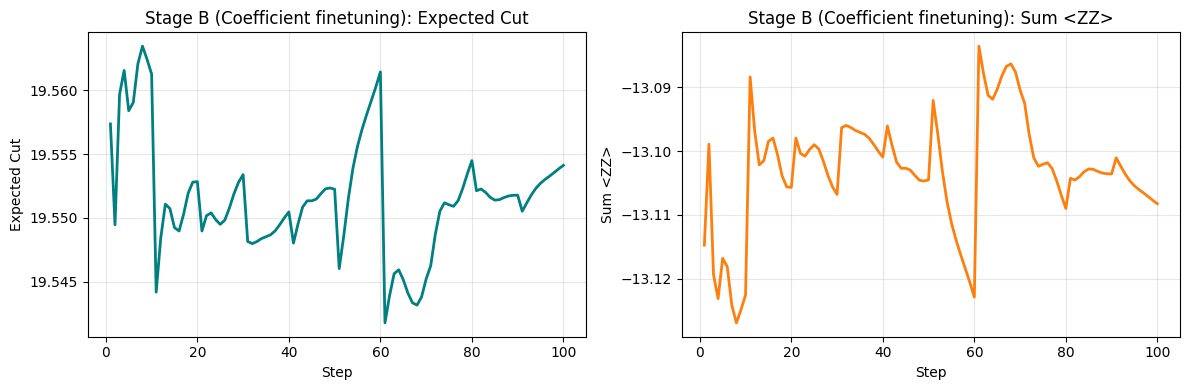

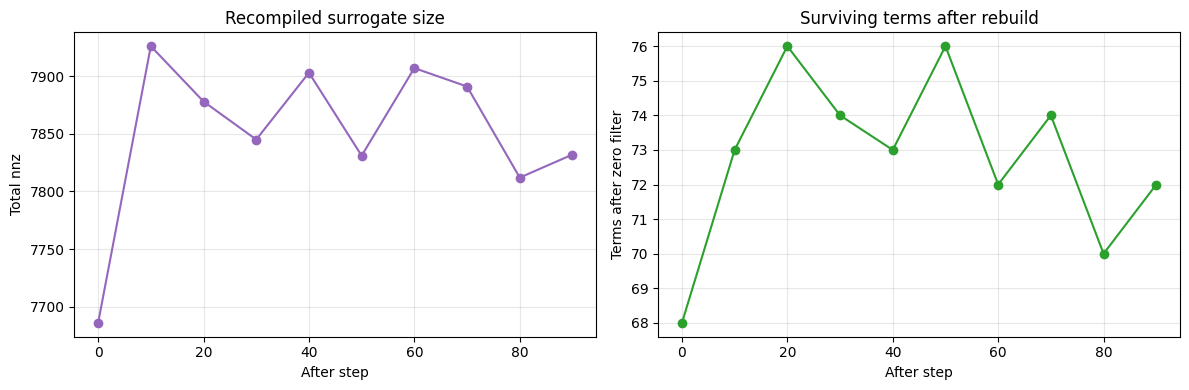

In [6]:
coeff_history, coeff_checkpoints, coeff_final_thetas_np, coeff_rebuild_log = train_with_periodic_rebuild(
    start_thetas_np=trained_thetas_mw_np,
    n_edges=m_edges,
    steps=COEFF_FINETUNE_STEPS,
    lr=LR_COEFF,
    checkpoint_steps=CHECKPOINT_STEPS_COEFF,
    build_min_abs=COEFF_BUILD_MIN_ABS,
    rebuild_interval=COEFF_REBUILD_INTERVAL,
    stage_name='coeff-finetune',
)

coeff_log = {
    'config': config_payload,
    'graph_path': str(OUTPUT_DIR / 'graph_edges.json'),
    'start_thetas_from_mw_stage': trained_thetas_mw_np.tolist(),
    'final_thetas': coeff_final_thetas_np.tolist(),
    'checkpoint_thetas': coeff_checkpoints,
    'history': coeff_history,
    'rebuild_log': coeff_rebuild_log,
}
save_json(OUTPUT_DIR / 'coeff_finetune_log.json', coeff_log)

coeff_initial_cut = coeff_history[0]['expected_cut'] if coeff_history else None
coeff_final_cut = coeff_history[-1]['expected_cut'] if coeff_history else None
print(f'Coeff stage initial expected cut: {coeff_initial_cut:.6f}')
print(f'Coeff stage final expected cut:   {coeff_final_cut:.6f}')
print(f'Net coeff-stage gain:            {coeff_final_cut - coeff_initial_cut:+.6f}')

plot_history(coeff_history, 'Stage B (Coefficient finetuning)', save_path=OUTPUT_DIR / 'coeff_finetune_curve.png')

rebuild_steps = [row['after_step'] for row in coeff_rebuild_log]
rebuild_nnz = [row['nnz_total'] for row in coeff_rebuild_log]
rebuild_terms = [row['terms_after_zero_filter'] for row in coeff_rebuild_log]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rebuild_steps, rebuild_nnz, marker='o', color='tab:purple')
axes[0].set_xlabel('After step')
axes[0].set_ylabel('Total nnz')
axes[0].set_title('Recompiled surrogate size')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rebuild_steps, rebuild_terms, marker='o', color='tab:green')
axes[1].set_xlabel('After step')
axes[1].set_ylabel('Terms after zero filter')
axes[1].set_title('Surviving terms after rebuild')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'coeff_rebuild_diagnostics.png', dpi=160)
plt.show()


In [7]:
run_summary = {
    'config': config_payload,
    'graph_path': str(OUTPUT_DIR / 'graph_edges.json'),
    'mw_training_log': str(OUTPUT_DIR / 'mw_training_log.json'),
    'coeff_finetune_log': str(OUTPUT_DIR / 'coeff_finetune_log.json'),
    'mw_initial_expected_cut': float(mw_history[0]['expected_cut']),
    'mw_final_expected_cut': float(mw_history[-1]['expected_cut']),
    'coeff_initial_expected_cut': float(coeff_history[0]['expected_cut']),
    'coeff_final_expected_cut': float(coeff_history[-1]['expected_cut']),
    'mw_final_thetas': trained_thetas_mw_np.tolist(),
    'coeff_final_thetas': coeff_final_thetas_np.tolist(),
}
save_json(OUTPUT_DIR / 'run_summary.json', run_summary)
print(json.dumps(run_summary, indent=2))


{
  "config": {
    "run_name": "Q15_L5_p0p25_mw3_seed42_bma1em03",
    "n_qubits": 15,
    "p_layers": 5,
    "edge_prob": 0.25,
    "seed": 42,
    "max_weight": 3,
    "delta_t": 0.8,
    "init_strategy": "flattened_tqa",
    "flatten_alpha": 0.5,
    "mw_train_steps": 150,
    "coeff_finetune_steps": 100,
    "lr_mw": 0.05,
    "lr_coeff": 0.01,
    "coeff_build_min_abs": 0.001,
    "coeff_rebuild_interval": 10,
    "checkpoint_steps_mw": [
      1,
      10,
      50,
      150
    ],
    "checkpoint_steps_coeff": [
      1,
      10,
      50,
      100
    ],
    "chunk_size": 20000000,
    "parallel_compile": false,
    "device": "cuda",
    "preset": "hybrid"
  },
  "graph_path": "/home/ubuntu/PPS-lab/test_qaoa/mw_training_coeff_finetuning_results/Q15_L5_p0p25_mw3_seed42_bma1em03/graph_edges.json",
  "mw_training_log": "/home/ubuntu/PPS-lab/test_qaoa/mw_training_coeff_finetuning_results/Q15_L5_p0p25_mw3_seed42_bma1em03/mw_training_log.json",
  "coeff_finetune_log": "/home/ubun

## 5. Optional CUDA-Q Sampling

아래 셀들은 `qaoa.ipynb`와 비슷하게 checkpoint theta들의 샘플링 분포를 비교하기 위한 준비입니다.
기본 비교 대상은 `mw_final`, `coeff_step_10`, `coeff_step_50`, `coeff_final`입니다.


In [8]:
try:
    import cudaq
    CUDA_Q_AVAILABLE = True
except Exception as exc:
    CUDA_Q_AVAILABLE = False
    CUDA_Q_IMPORT_ERROR = exc
    print(f'CUDA-Q import failed: {exc}')

from typing import Any, Dict, Optional


def _bits_from_code(code: int, n_qubits: int) -> np.ndarray:
    bits = np.zeros((int(n_qubits),), dtype=np.uint8)
    for q in range(int(n_qubits)):
        bits[q] = (int(code) >> q) & 1
    return bits


def _parse_counts_keys(counts: Dict[str, int], n_qubits: int, bit_order: str) -> Dict[int, int]:
    out: Dict[int, int] = {}
    for k, v in counts.items():
        ks = str(k).strip()
        if all(ch in ('0', '1') for ch in ks) and len(ks) == int(n_qubits):
            code = 0
            if str(bit_order) == 'le':
                for i, ch in enumerate(ks):
                    code |= (int(ch) & 1) << i
            else:
                for i, ch in enumerate(ks):
                    code |= (int(ch) & 1) << (int(n_qubits) - 1 - i)
        elif ks.isdigit():
            code = int(ks)
        else:
            raise ValueError(f'invalid bitstring key: {k}')
        out[int(code)] = int(v)
    return out


def cut_value_from_bits(bits01, edges) -> int:
    val = 0
    for u, v in edges:
        val += int(int(bits01[int(u)]) != int(bits01[int(v)]))
    return int(val)


def get_cut_values(counts_dict, n_qubits, edges):
    code_counts = _parse_counts_keys(counts_dict, n_qubits, 'le')
    vals = []
    for code, cnt in code_counts.items():
        bits = _bits_from_code(code, n_qubits)
        cut = cut_value_from_bits(bits, edges)
        vals.extend([cut] * cnt)
    return np.asarray(vals, dtype=np.int64)


def _try_cudaq_sample(*, n_qubits: int, edges, p_layers: int, thetas: np.ndarray, shots: int, seed: Optional[int]):
    if not CUDA_Q_AVAILABLE:
        raise RuntimeError(f'CUDA-Q is not available: {CUDA_Q_IMPORT_ERROR}')

    theta_np = np.asarray(thetas, dtype=np.float64).reshape(-1)
    params_list = [float(x) for x in theta_np.tolist()]

    kernel, params = cudaq.make_kernel(list[float])
    q = kernel.qalloc(int(n_qubits))

    for i in range(int(n_qubits)):
        kernel.h(q[i])

    for layer in range(int(p_layers)):
        gamma_idx = 2 * layer
        beta_idx = 2 * layer + 1
        for (u, v) in edges:
            uu = int(u)
            vv = int(v)
            kernel.cx(q[uu], q[vv])
            kernel.rz(params[gamma_idx], q[vv])
            kernel.cx(q[uu], q[vv])
        for i in range(int(n_qubits)):
            kernel.rx(params[beta_idx], q[i])

    kernel.mz(q)

    if seed is not None:
        cudaq.set_random_seed(int(seed))

    counts = cudaq.sample(kernel, params_list, shots_count=int(shots))
    return {str(k): int(v) for k, v in counts.items()}


In [9]:
SAMPLE_SHOTS = 4000
SAMPLE_SEED = SEED

sample_theta_dict = {
    'mw_final': np.asarray(mw_checkpoints.get(f'step_{MW_TRAIN_STEPS}', trained_thetas_mw_np), dtype=np.float64),
    'coeff_step_10': np.asarray(coeff_checkpoints.get('step_10', coeff_final_thetas_np), dtype=np.float64),
    'coeff_step_50': np.asarray(coeff_checkpoints.get('step_50', coeff_final_thetas_np), dtype=np.float64),
    'coeff_final': np.asarray(coeff_checkpoints.get(f'step_{COEFF_FINETUNE_STEPS}', coeff_final_thetas_np), dtype=np.float64),
}

sampled_counts = {}
for label, theta_np in sample_theta_dict.items():
    print(f'Sampling {label} ...')
    sampled_counts[label] = _try_cudaq_sample(
        n_qubits=N_QUBITS,
        edges=edges,
        p_layers=P_LAYERS,
        thetas=theta_np,
        shots=SAMPLE_SHOTS,
        seed=SAMPLE_SEED,
    )

save_json(OUTPUT_DIR / 'sampling_counts.json', sampled_counts)
print(f'Saved sampling counts to {OUTPUT_DIR / "sampling_counts.json"}')


Sampling mw_final ...
Sampling coeff_step_10 ...
Sampling coeff_step_50 ...
Sampling coeff_final ...
Saved sampling counts to /home/ubuntu/PPS-lab/test_qaoa/mw_training_coeff_finetuning_results/Q15_L5_p0p25_mw3_seed42_bma1em03/sampling_counts.json


--- mw_final ---
{
  "mean_cut": 20.55625,
  "max_cut": 22,
  "min_cut": 11
}
--- coeff_step_10 ---
{
  "mean_cut": 20.51,
  "max_cut": 22,
  "min_cut": 11
}
--- coeff_step_50 ---
{
  "mean_cut": 20.5405,
  "max_cut": 22,
  "min_cut": 10
}
--- coeff_final ---
{
  "mean_cut": 20.536,
  "max_cut": 22,
  "min_cut": 11
}


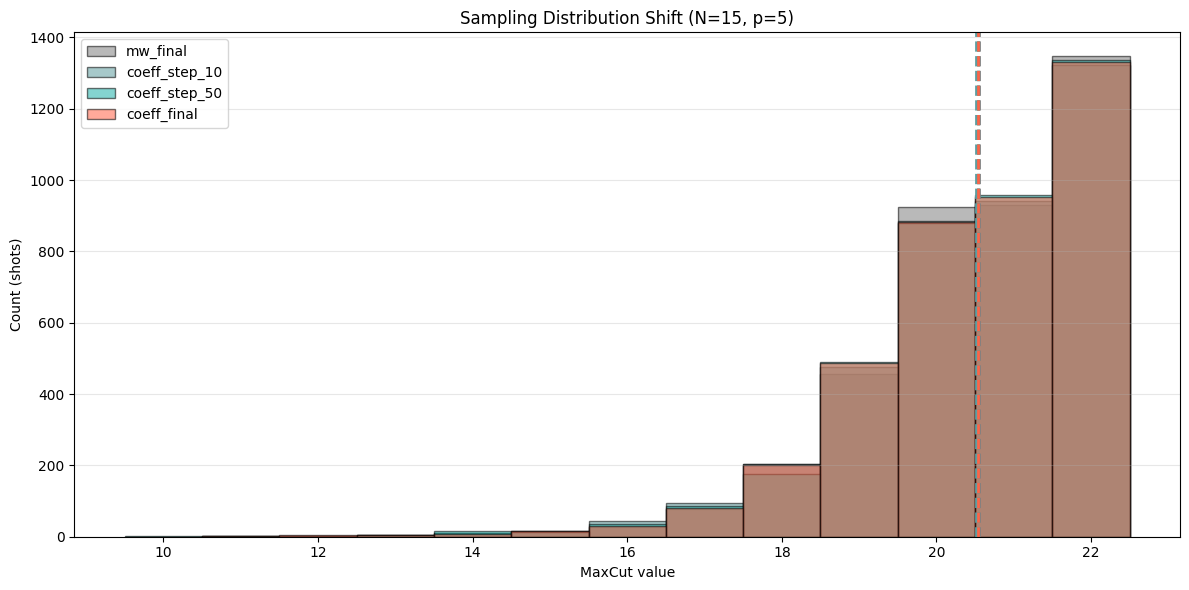

In [12]:
cuts_by_label = {label: get_cut_values(counts, N_QUBITS, edges) for label, counts in sampled_counts.items()}

sampling_summary = {}
for label, vals in cuts_by_label.items():
    sampling_summary[label] = {
        'mean_cut': float(np.mean(vals)),
        'max_cut': int(np.max(vals)),
        'min_cut': int(np.min(vals)),
    }
    print(f'--- {label} ---')
    print(json.dumps(sampling_summary[label], indent=2))

all_cuts = np.concatenate(list(cuts_by_label.values()))
bins = np.arange(int(np.min(all_cuts)), int(np.max(all_cuts)) + 2) - 0.5

plt.figure(figsize=(12, 6))
colors = ['gray', '#5f9ea0', '#20b2aa', '#ff6347']
for color, (label, vals) in zip(colors, cuts_by_label.items()):
    plt.hist(vals, bins=bins, alpha=0.55, label=label, edgecolor='black', density=False, color=color)
    plt.axvline(np.mean(vals), linestyle='--', linewidth=2, color=color)

plt.xlabel('MaxCut value')
plt.ylabel('Count (shots)')
plt.title(f'Sampling Distribution Shift (N={N_QUBITS}, p={P_LAYERS})')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sampling_histogram.png', dpi=160)
plt.show()

save_json(OUTPUT_DIR / 'sampling_summary.json', sampling_summary)


In [ ]:
import matplotlib.pyplot as plt
start_thetas = np.array([
        0.4,
        -0.4000000000000001,
        0.5333333333333333,
        -0.2666666666666667,
        0.6666666666666667,
        -0.13333333333333336
      ])
final_thetas= np.array([
        0.4247528719776978,
        -1.063090474425143,
        0.8048734909537345,
        -0.7200651143926983,
        0.9267352398351238,
        -0.38301624136668316
      ])

# 짝수와 홀수번째 인덱스를 구분해서 시각화
fig, ax = plt.subplots(1, 2, figsize=(10, 6))
x = np.arange(len(start_thetas))
ax[0].plot(x, start_thetas[::2], marker='o', label='Start Thetas', color='blue')
ax[0].plot(x, final_thetas[::2], marker='o', label='Final Thetas', color='orange')
ax[0].set_xticks(x)
ax[0].set_xticklabels([f'θ{i}' for i in x])
ax[0].set_xlabel('Parameter Index')
ax[0].set_ylabel('Theta Value')
ax[0].set_title('Comparison of Start and Final Thetas - Gamma')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(x, start_thetas[1::2], marker='o', label='Start Thetas', color='blue')
ax[1].plot(x, final_thetas[1::2], marker='o', label='Final Thetas', color='orange')
ax[1].set_xticks(x)
ax[1].set_xticklabels([f'θ{i}' for i in x])
ax[1].set_xlabel('Parameter Index')
ax[1].set_ylabel('Theta Value')
ax[1].set_title('Comparison of Start and Final Thetas - Beta')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'theta_comparison.png', dpi=160)
plt.show()